In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import glob
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar

maxz=200
argofolder = '../data/ARGO/'


In [4]:
extent_gyre =[141,145,-63,-61.5]
extent = [139, 150,-68,-64]
wider_area = [130, 160, -68, -60]


In [5]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation
elevation = elevation_.sel(latitude = slice(wider_area[2], wider_area[3]), longitude = slice(wider_area[0],wider_area[1]))

In [6]:
fname = '../data/qc_profile_ds_2dbar.nc'
ds = xr.open_dataset(fname).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [7]:
ds = ds.sel(pres=slice(0,maxz))

In [8]:
elevation = GEBCO(coarsen_factor=40).ds.elevation
#extent =[100,160,-69,-63]
mertz = Region('Mertz',extent)
gyre = Region('Gyre',extent_gyre)

In [9]:
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da

In [10]:
sla = SLA(deg=0.25).da
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [11]:
pressure_axis = ds.pres.values #np.arange(4,102,2)

In [12]:
# also add argo
profiles=[]
for file in glob.glob(argofolder + '*nc'):
    dsa = xr.open_dataset(file)
    for t in dsa.TIME:
        if t < pd.Timestamp(2022,1,1):
            dst = dsa.sel(TIME=t)
            if (dst.LATITUDE < extent[3]) & (dst.LONGITUDE < extent[1]):
                dstn = dst.swap_dims({'DEPTH':'PRES_ADJUSTED'}).dropna(dim='PRES_ADJUSTED')
                if elevation.interp({'latitude':dstn.LATITUDE,'longitude':dstn.LONGITUDE}) > -1000:
                    if len(dstn.PRES)>0:
                        pnew = dstn.interp({'PRES_ADJUSTED':pressure_axis}).expand_dims(['TIME']).drop_vars([
     'TRAJECTORY', 'TIME_QC', 'POSITION_QC', 'DC_REFERENCE', 'DIRECTION', 'PRES_QC', 'PRES_ADJUSTED_QC', 'TEMP_ADJUSTED_QC','PSAL_ADJUSTED_QC','PRES_CORE','PRES'
    ])
                        pnew = pnew.assign_coords(
                            LATITUDE=("TIME", [pnew.LATITUDE.values]),
                            LONGITUDE=("TIME", [pnew.LONGITUDE.values])
                        )
                        profiles.append(pnew)

print('Found {} profiles. Merging into ds...'.format(len(profiles)))
argods=xr.merge(profiles).rename({
    'TIME':'time',
    'LONGITUDE':'lon',
    'LATITUDE':'lat',
    'PRES_ADJUSTED':'pres',
    'TEMP_ADJUSTED':'temp',
    'PSAL_ADJUSTED':'psal'})

Found 85 profiles. Merging into ds...


In [13]:
argods

<xarray.Dataset> Size: 140kB
Dimensions:  (pres: 101, time: 85)
Coordinates:
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
  * time     (time) datetime64[ns] 680B 2012-01-11T14:29:16 ... 2016-03-10T18...
    lat      (time) float32 340B -66.91 -66.91 -66.91 ... -65.96 -65.96 -65.96
    lon      (time) float32 340B 145.4 145.4 145.4 144.9 ... 143.7 143.7 143.7
Data variables:
    temp     (time, pres) float64 69kB -1.107 -1.105 -1.109 ... -1.373 -1.367
    psal     (time, pres) float64 69kB 34.03 34.03 34.04 ... 34.51 34.51 34.51
Attributes: (12/50)
    platform_code:                  7900329
    platform_name:                  APEX Profiling Float SBE
    wmo_platform_code:              7900329
    ices_platform_code:              
    coriolis_platform_code:         7900329
    comment:                         
    ...                             ...
    date_modified:                  2025-08-06T09:49:04Z
    history:                        2025-08-06T09:49:04Z : Creation
    publisher_email:                cmems-service@ifremer.fr
    publisher_name:                 Copernicus Marine Service
    publisher_url:                  https://marine.copernicus.eu/ http://www....
    publisher_institution:          Ifremer

In [14]:
ds_both = xr.merge([ds.drop_duplicates(dim='time'),argods],compat='override')

In [15]:
ds_both

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1996, pres: 101)
Coordinates:
  * time     (time) datetime64[ns] 16kB 2004-10-28T21:36:00.003089408 ... 202...
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
    lon      (time) float64 16kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 16kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
    n_prof   (time) float64 16kB 5.668e+05 1.199e+05 ... 2.989e+05 8.11e+05
Data variables:
    temp     (time, pres) float64 2MB nan nan nan nan ... -0.303 -0.258 -0.199
    psal     (time, pres) float64 2MB nan nan nan nan ... 34.61 34.62 34.62
    dsource  (time) object 16kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 16kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 806kB nan nan nan nan ... 34.78 34.78 34.79
    ctemp    (time, pres) float32 806kB nan nan nan ... -0.3011 -0.2561 -0.1972
    rho      (time, pres) float32 806kB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 16kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [16]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1926, pres: 101)
Coordinates:
    lon      (time) float64 15kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 15kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
  * time     (time) datetime64[ns] 15kB 2004-10-28T21:36:00.003089408 ... 202...
    n_prof   (time) int64 15kB 566783 119908 120584 ... 811038 298884 811039
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
Data variables:
    temp     (time, pres) float64 2MB nan nan nan nan ... -0.303 -0.258 -0.199
    psal     (time, pres) float64 2MB nan nan nan nan ... 34.61 34.62 34.62
    dsource  (time) object 15kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 15kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 778kB nan nan nan nan ... 34.78 34.78 34.79
    ctemp    (time, pres) float32 778kB nan nan nan ... -0.3011 -0.2561 -0.1972
    rho      (time, pres) float32 778kB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 15kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [17]:
ds_both

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 1991, pres: 101)
Coordinates:
  * time     (time) datetime64[ns] 16kB 2004-10-28T21:36:00.003089408 ... 202...
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
    lon      (time) float64 16kB 145.2 142.5 143.5 142.9 ... 146.8 140.6 146.7
    lat      (time) float64 16kB -67.06 -64.01 -64.21 ... -64.97 -64.06 -64.98
    n_prof   (time) float64 16kB 5.668e+05 1.199e+05 ... 2.989e+05 8.11e+05
Data variables:
    temp     (time, pres) float64 2MB nan nan nan nan ... -0.303 -0.258 -0.199
    psal     (time, pres) float64 2MB nan nan nan nan ... 34.61 34.62 34.62
    dsource  (time) object 16kB 'CTD' 'Argo' 'Argo' ... 'SOCCOM' 'Argo' 'SOCCOM'
    mld      (time) float64 16kB 381.8 83.76 63.96 78.81 ... 27.62 47.43 39.6
    asal     (time, pres) float32 804kB nan nan nan nan ... 34.78 34.78 34.79
    ctemp    (time, pres) float32 804kB nan nan nan ... -0.3011 -0.2561 -0.1972
    rho      (time, pres) float32 804kB nan nan nan ... 1.028e+03 1.028e+03
    mlp      (time) float64 16kB 386.0 82.0 60.0 78.0 ... 36.0 28.0 46.0 40.0
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [18]:
meop=MEOP(extent=extent)
meop.load_profiles_for_spira(pressure_axis=pressure_axis)

100%|██████████| 82/82 [02:03<00:00,  1.51s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:114: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [32]:
ds_all = xr.merge([meop.ds.drop_duplicates(dim='time'),ds_both],compat='override')

In [33]:
ds_all

<xarray.Dataset> Size: 34MB
Dimensions:       (pres: 101, time: 11706)
Coordinates:
  * pres          (pres) int64 808B 0 2 4 6 8 10 12 ... 190 192 194 196 198 200
  * time          (time) datetime64[ns] 94kB 2004-10-28T21:36:00.003089408 .....
    lat           (time) float64 94kB nan nan nan nan ... -66.65 -66.61 -66.61
    lon           (time) float64 94kB nan nan nan nan ... 140.0 139.8 139.8
    n_prof        (time) float64 94kB 5.668e+05 1.199e+05 1.206e+05 ... nan nan
Data variables:
    profile_code  (time) object 94kB nan nan ... 'wd30-639-Vert-22'
    temp          (time, pres) float64 9MB nan nan nan ... -1.302 -1.302 -1.302
    psal          (time, pres) float64 9MB nan nan nan nan ... 34.28 34.28 34.28
    dsource       (time) object 94kB nan nan nan nan ... 'MEOP-' 'MEOP-' 'MEOP-'
    mld           (time) float64 94kB 381.8 83.76 63.96 78.81 ... nan nan nan
    asal          (time, pres) float32 5MB nan nan nan nan ... nan nan nan nan
    ctemp         (time, pres) float32 5MB nan nan nan nan ... nan nan nan nan
    rho           (time, pres) float32 5MB nan nan nan nan ... nan nan nan nan
    mlp           (time) float64 94kB 386.0 82.0 60.0 78.0 ... nan nan nan nan

In [37]:
argods

<xarray.Dataset> Size: 131kB
Dimensions:  (pres: 101, time: 80)
Coordinates:
  * pres     (pres) int64 808B 0 2 4 6 8 10 12 ... 188 190 192 194 196 198 200
  * time     (time) datetime64[ns] 640B 2012-01-11T14:29:16 ... 2016-03-10T18...
    lat      float32 4B -66.91
    lon      float32 4B 145.4
Data variables:
    temp     (time, pres) float64 65kB -1.107 -1.105 -1.109 ... nan nan nan
    psal     (time, pres) float64 65kB 34.03 34.03 34.04 34.04 ... nan nan nan
Attributes: (12/50)
    platform_code:                  7900329
    platform_name:                  APEX Profiling Float SBE
    wmo_platform_code:              7900329
    ices_platform_code:              
    coriolis_platform_code:         7900329
    comment:                         
    ...                             ...
    date_modified:                  2025-08-06T09:49:04Z
    history:                        2025-08-06T09:49:04Z : Creation
    publisher_email:                cmems-service@ifremer.fr
    publisher_name:                 Copernicus Marine Service
    publisher_url:                  https://marine.copernicus.eu/ http://www....
    publisher_institution:          Ifremer

In [ ]:
dsp = xr.merge([ds.drop_duplicates('time'),argods])
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(dsp.lon,dsp.lat,c=dsp.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

ValueError: cannot reindex or align along dimension 'time' because the (pandas) index has duplicate values

/tmp/ipykernel_6622/1096732169.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_all['elevation'] = elevation.interp(latitude=ds_all.lat,longitude=ds_all.lon).drop(['longitude','latitude'])


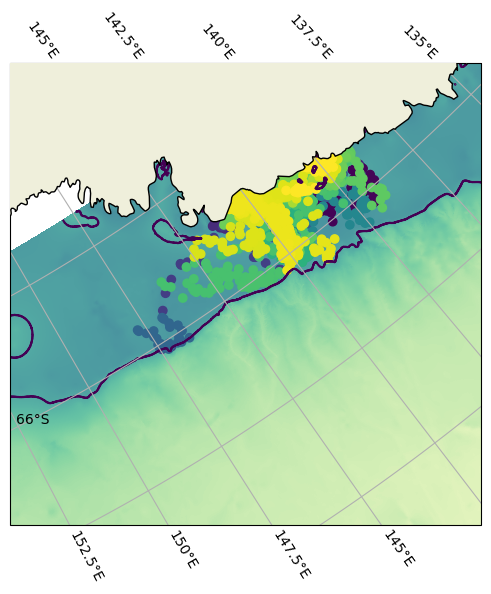

In [ ]:
ds_all['month'] = ds_all.time.dt.month
ds_all['elevation'] = elevation.interp(latitude=ds_all.lat,longitude=ds_all.lon).drop(['longitude','latitude'])
ds_all = ds_all.where(ds_all.elevation > -1000,drop=True)


In [31]:
ds_all

<xarray.Dataset> Size: 26MB
Dimensions:       (time: 9108, pres: 101)
Coordinates:
  * pres          (pres) int64 808B 0 2 4 6 8 10 12 ... 190 192 194 196 198 200
  * time          (time) datetime64[ns] 73kB 2007-02-20T15:19:59 ... 2024-02-...
    lat           (time) float64 73kB -66.62 -66.56 -66.59 ... -66.61 -66.61
    lon           (time) float64 73kB 139.9 140.0 140.0 ... 140.0 139.8 139.8
    n_prof        (time) float64 73kB nan nan nan nan nan ... nan nan nan nan
Data variables:
    profile_code  (time) object 73kB 'wd3-CTD2-07' ... 'wd30-639-Vert-22'
    temp          (time, pres) float64 7MB nan nan nan ... -1.302 -1.302 -1.302
    psal          (time, pres) float64 7MB nan nan nan nan ... 34.28 34.28 34.28
    dsource       (time) object 73kB 'MEOP-' 'MEOP-' 'MEOP-' ... 'MEOP-' 'MEOP-'
    mld           (time) float64 73kB nan nan nan nan nan ... nan nan nan nan
    asal          (time, pres) float32 4MB nan nan nan nan ... nan nan nan nan
    ctemp         (time, pres) float32 4MB nan nan nan nan ... nan nan nan nan
    rho           (time, pres) float32 4MB nan nan nan nan ... nan nan nan nan
    mlp           (time) float64 73kB nan nan nan nan nan ... nan nan nan nan
    month         (time) float64 73kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
    elevation     (time) float64 73kB -54.28 -296.9 -125.9 ... -105.2 -133.7

In [ ]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(ds_all.lon,ds_all.lat,c=ds_all.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

In [27]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons = get_seasons(ds_all)
print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))


3484
1181
1573
3070


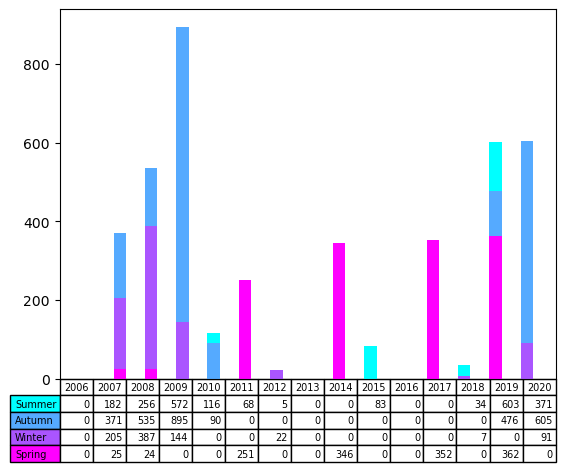

In [23]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2006,2021,1)
ally = xr.DataArray(cols, coords={'year':cols})
prep4table = lambda season: seasons[season].groupby('time.year').count().dsource.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')

In [25]:
gyre_index = xr.open_dataarray('gyre_index.nc')


preparing data


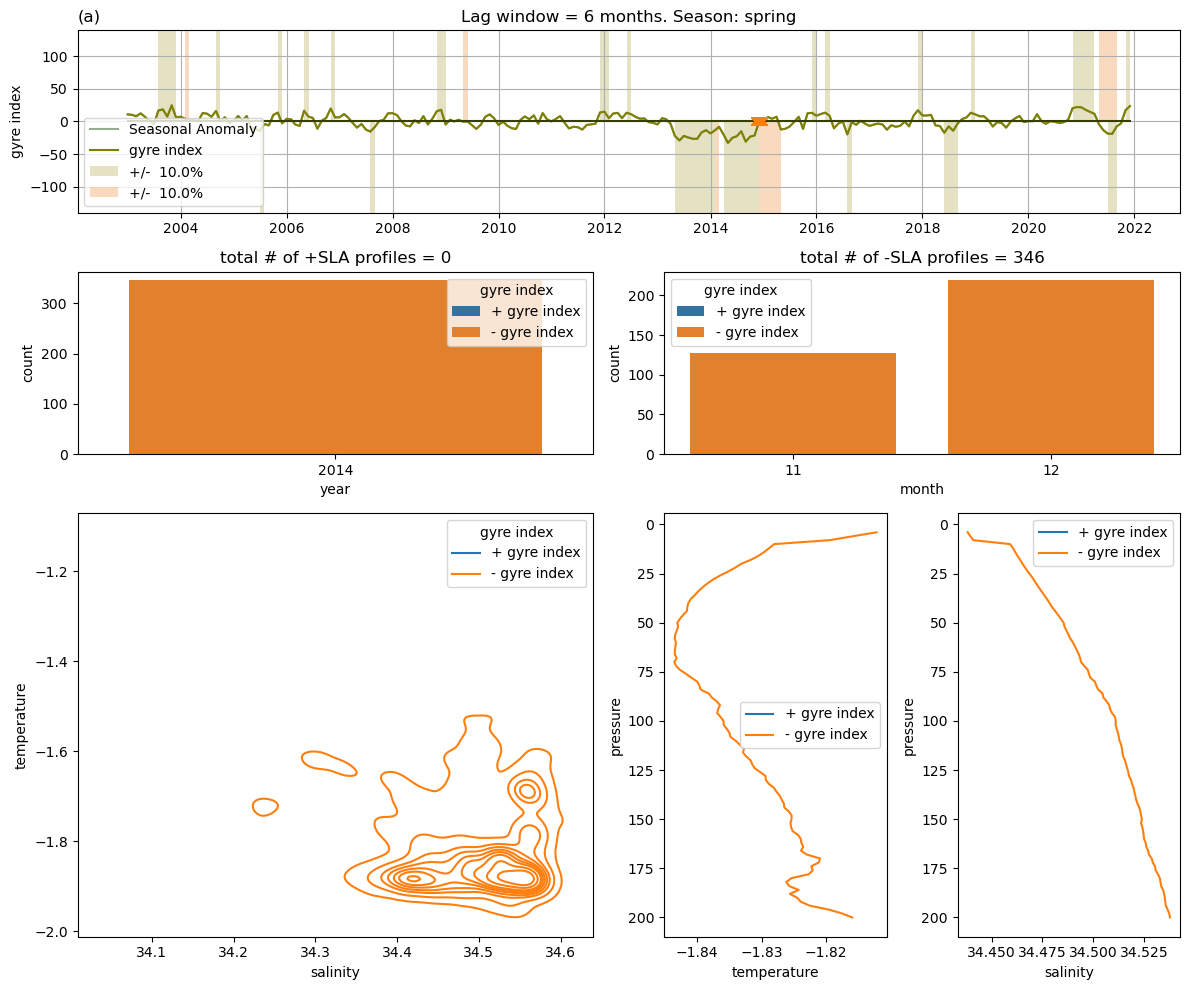

In [28]:
season='spring'
background_data = gyre_index
idx_data = background_data#.rolling(time=12,center=True).mean('time')
title='gyre index'
ylim=[-140,140]
lagwindow=6
cmp = Composite(idx_data,title,lag=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

preparing data


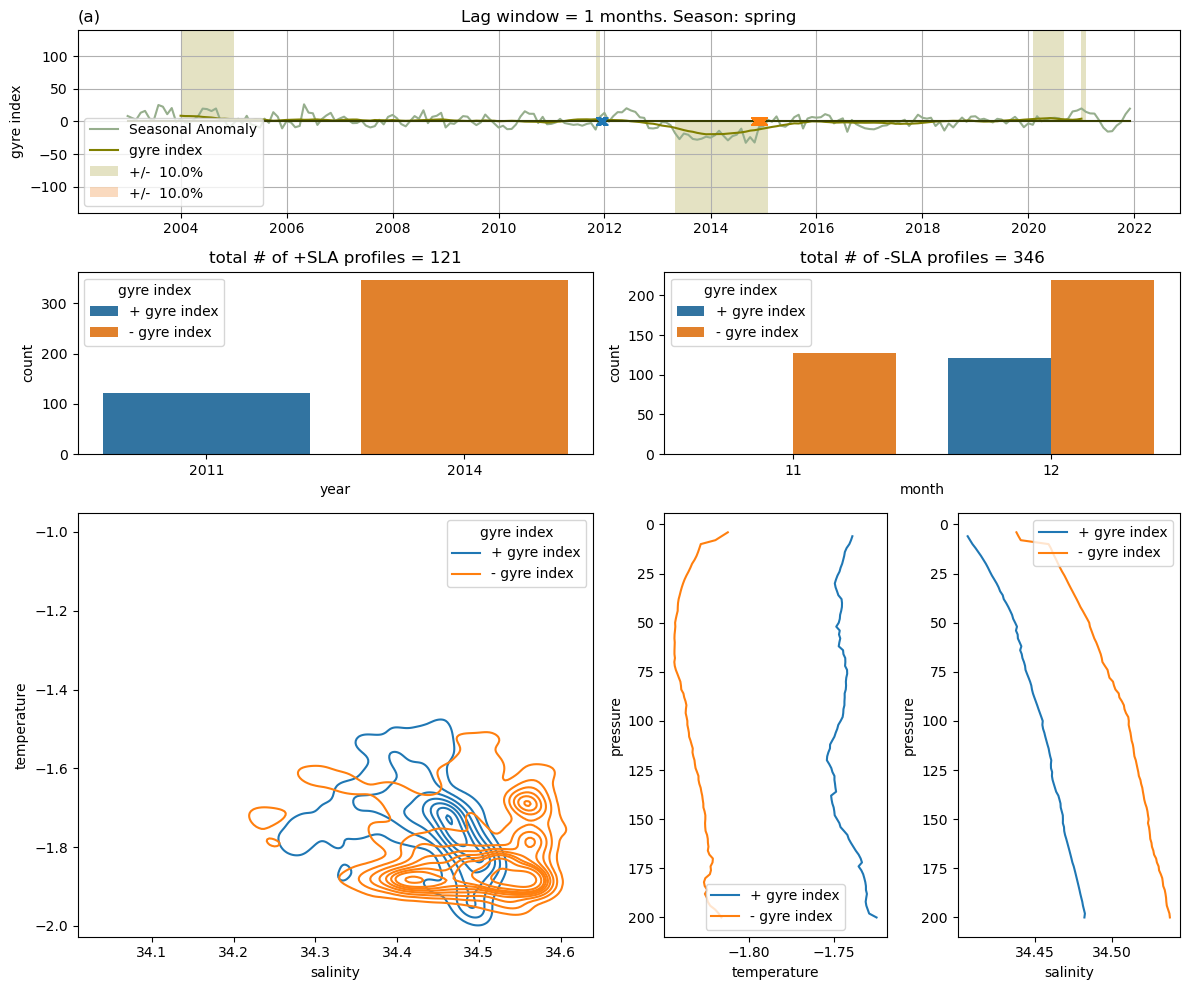

In [ ]:
season='spring'
background_data = -gyre_index_eof.sel(mode=1)
idx_data = background_data.rolling(time=24,center=True).mean('time')
title='gyre index'
ylim=[-140,140]
lagwindow=1
cmp = Composite(idx_data,title,lag=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

In [ ]:
season='spring'
background_data = xr.open_dataarray('scores_eof2.nc') - 15
idx_data = background_data.rolling(time=24,center=True).mean('time')
title='EOF'
ylim=[-100,100]
lagwindow=4


cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

NameError: name 'xr' is not defined

preparing data


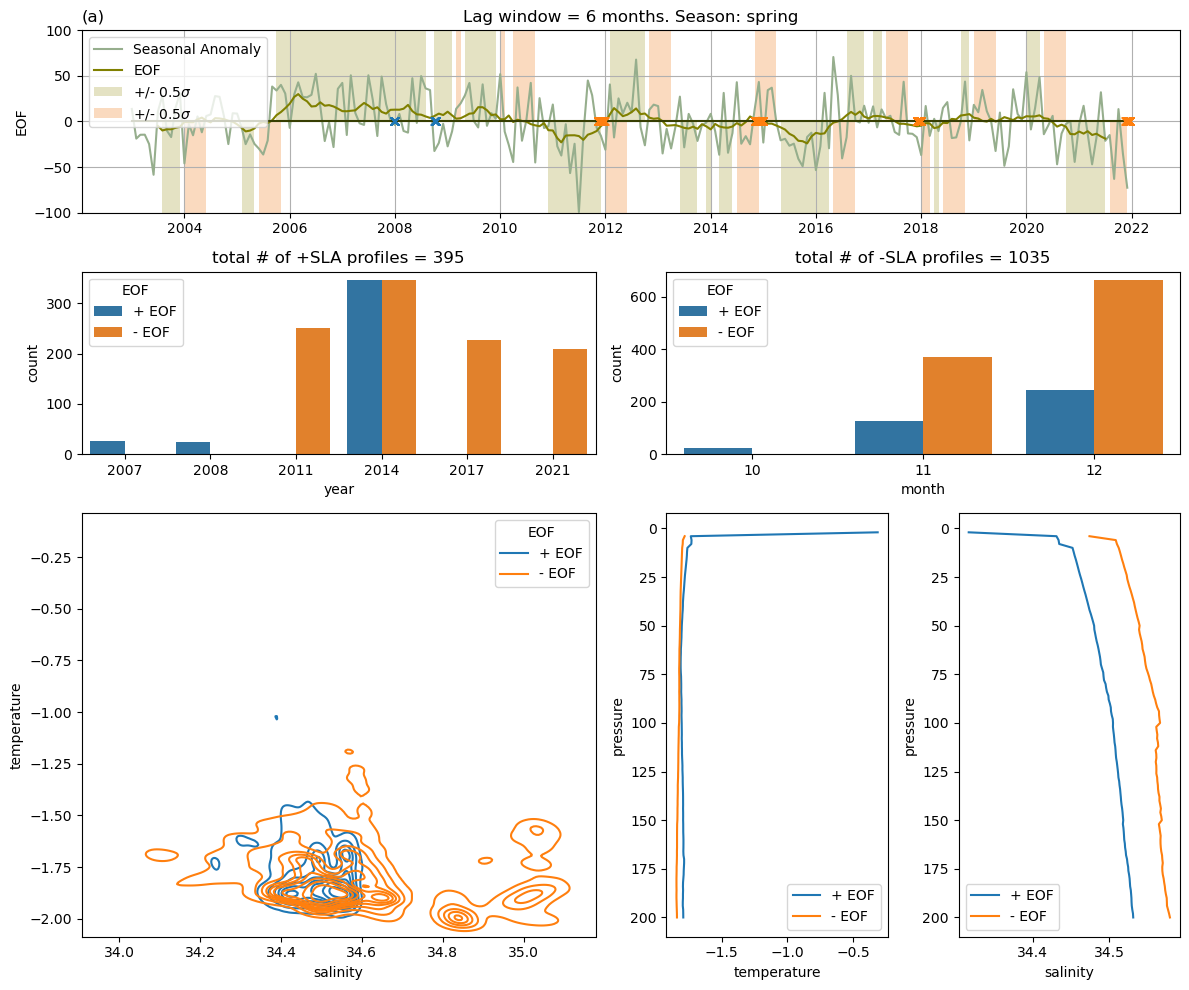

In [ ]:
season='spring'
background_data = xr.open_dataarray('scores_eof3.nc')
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='EOF'
ylim=[-100,100]
lagwindow=6
cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

In [26]:
season='spring'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 12

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2,hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

TypeError: Composite.__init__() got an unexpected keyword argument 'lagwindow'

In [27]:
season='autumn'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 3

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2, hue_order=['+ {}'.format(title), '- {}'.format(title)])
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3, hue_order=['+ {}'.format(title), '- {}'.format(title)])
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name, hue_order=['+ {}'.format(title), '- {}'.format(title)])

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

TypeError: Composite.__init__() got an unexpected keyword argument 'lagwindow'

In [28]:
season='summer'
background_data = sla_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SLA'
ylim=[-12,12]
lagwindow = 6

cmp = Composite(idx_data,title,lagwindow=lagwindow)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(lagwindow,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_profiles, x='year', hue=cmp.idx_name,ax=ax2)
sns.countplot(cmp.sns_profiles, x='month', hue=cmp.idx_name,ax=ax3)
ax2.set_title('total # of +SLA profiles = {}'.format(len(cmp.t_pos)))
ax3.set_title('total # of -SLA profiles = {}'.format(len(cmp.t_neg)))

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name)

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()

TypeError: Composite.__init__() got an unexpected keyword argument 'lagwindow'